### Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [ ]:
df = pd.read_csv('../../data/preproccedData/Augmented_PreProccedNutrationParameters.csv')

In [7]:
df.head()

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk,NutritionRisk
0,24,1,160.39,53.08,2,1,1,1,1,2,2106.59,1,16.60,29.69,54.09
1,24,1,158.47,58.42,1,2,1,0,1,1,2106.58,1,18.71,31.04,36.07
2,28,0,146.93,50.97,3,3,1,0,2,2,2106.58,1,18.99,28.55,18.03
3,24,0,156.55,59.46,2,1,1,1,3,5,1378.17,2,19.52,36.28,36.04
4,22,0,147.91,48.84,2,1,1,1,2,3,2106.59,3,17.95,24.35,18.03


#### Preparing X and Y variables

In [9]:
X = df.drop(columns=['NutritionRisk'],axis=1)

In [10]:
X.head()

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk
0,24,1,160.39,53.08,2,1,1,1,1,2,2106.59,1,16.60,29.69
1,24,1,158.47,58.42,1,2,1,0,1,1,2106.58,1,18.71,31.04
2,28,0,146.93,50.97,3,3,1,0,2,2,2106.58,1,18.99,28.55
3,24,0,156.55,59.46,2,1,1,1,3,5,1378.17,2,19.52,36.28
4,22,0,147.91,48.84,2,1,1,1,2,3,2106.59,3,17.95,24.35


In [11]:
y = df['NutritionRisk']

In [12]:
y

0       65.170595
1       32.574707
2       16.287054
3       32.571449
4       16.278099
          ...    
1057    31.015505
1058    62.009145
1059    62.013591
1060    46.511077
1061    46.504442
Name: NutritionRisk, Length: 1062, dtype: float64

In [13]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [14]:
X = preprocessor.fit_transform(X)

In [15]:
df

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk,NutritionRisk
0,24,1,160.39,53.08,2,1,1,1,1,2,2106.59,1,16.60,29.69,54.09
1,24,1,158.47,58.42,1,2,1,0,1,1,2106.58,1,18.71,31.04,36.07
2,28,0,146.93,50.97,3,3,1,0,2,2,2106.58,1,18.99,28.55,18.03
3,24,0,156.55,59.46,2,1,1,1,3,5,1378.17,2,19.52,36.28,36.04
4,22,0,147.91,48.84,2,1,1,1,2,3,2106.59,3,17.95,24.35,18.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1057,45,1,154.66,83.24,2,3,1,0,1,6,1747.22,4,42.04,74.28,34.79
1058,48,1,160.80,95.92,4,2,1,1,4,2,3131.04,2,44.80,72.60,69.58
1059,48,0,163.85,94.12,5,3,1,1,4,2,2858.49,3,42.32,67.35,69.56
1060,42,1,182.28,77.18,5,3,1,1,3,3,2422.06,2,28.05,51.86,52.17


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((849, 14), (213, 14))

In [20]:
df.head()

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk,NutritionRisk
0,24,1,160.39,53.08,2,1,1,1,1,2,2106.59,1,16.60,29.69,54.09
1,24,1,158.47,58.42,1,2,1,0,1,1,2106.58,1,18.71,31.04,36.07
2,28,0,146.93,50.97,3,3,1,0,2,2,2106.58,1,18.99,28.55,18.03
3,24,0,156.55,59.46,2,1,1,1,3,5,1378.17,2,19.52,36.28,36.04
4,22,0,147.91,48.84,2,1,1,1,2,3,2106.59,3,17.95,24.35,18.03


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define the preprocessing for numerical and categorical features
numerical_features = ['Age', 'Height', 'Weight', 'Carbohydrate_Consumption', 'Protein_Intake', 'Fat_Intake',]
categorical_features = ['Gender', 'Family_History', 'Thirst']

# Create a numerical transformer (standardize and impute missing values)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with the median
    ('scaler', StandardScaler())  # Scale numerical features
])

# Create a categorical transformer (encode and impute missing values)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with the most frequent category
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encode categorical variables
])

# Combine both transformations in a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Apply the transformations
X_transformed = preprocessor.fit_transform(df)


ValueError: A given column is not a column of the dataframe

In [21]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming evaluate_model() function is defined as:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "MLPRegressor": MLPRegressor(max_iter=500),  # Increasing max_iter for convergence
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, min_samples_split=10),
    "Random Forest Regressor":    RandomForestRegressor(max_depth=5, n_estimators=100, min_samples_split=10),
    "XGBRegressor":  XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
}

model_list = []
r2_list_train = []
r2_list_test = []

# Split the data (assuming X and y are your features and target variables)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Print model performance
    print(f"Model performance for {model_name} (Training set):")
    print(f"- RMSE: {model_train_rmse:.4f}")
    print(f"- MAE: {model_train_mae:.4f}")
    print(f"- R2: {model_train_r2:.4f}")
    print("-" * 40)
    
    print(f"Model performance for {model_name} (Test set):")
    print(f"- RMSE: {model_test_rmse:.4f}")
    print(f"- MAE: {model_test_mae:.4f}")
    print(f"- R2: {model_test_r2:.4f}")
    print("=" * 40)
    
    # Store model performance
    model_list.append(model_name)
    r2_list_train.append(model_train_r2)
    r2_list_test.append(model_test_r2)

# Create a DataFrame for comparison (optional)
model_performance_df = pd.DataFrame({
    'Model': model_list,
    'Train R2': r2_list_train,
    'Test R2': r2_list_test
})

print(model_performance_df)

Training MLPRegressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

Model performance for MLPRegressor (Training set):
- RMSE: 12.4461
- MAE: 10.0801
- R2: 0.5072
----------------------------------------
Model performance for MLPRegressor (Test set):
- RMSE: 12.3985
- MAE: 10.2008
- R2: 0.5123
Training Linear Regression...
Model performance for Linear Regression (Training set):
- RMSE: 12.3304
- MAE: 9.6923
- R2: 0.5163
----------------------------------------
Model performance for Linear Regression (Test set):
- RMSE: 12.9490
- MAE: 10.2962
- R2: 0.4680
Training Lasso...
Model performance for Lasso (Training set):
- RMSE: 12.5747
- MAE: 9.8077
- R2: 0.4970
----------------------------------------
Model performance for Lasso (Test set):
- RMSE: 13.3438
- MAE: 10.4592
- R2: 0.4351
Training Ridge...
Model performance for Ridge (Training set):
- RMSE: 12.3304
- MAE: 9.6918
- R2: 0.5163
----------------------------------------
Model performance for Ridge (Test set):
- RMSE: 12.9494
- MAE: 10.2955
- R2: 0.4680
Training K-Neighbors Regressor...
Model perform

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model performance for Random Forest Regressor (Training set):
- RMSE: 6.2405
- MAE: 4.7079
- R2: 0.8761
----------------------------------------
Model performance for Random Forest Regressor (Test set):
- RMSE: 7.1843
- MAE: 5.4325
- R2: 0.8363
Training XGBRegressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model performance for XGBRegressor (Training set):
- RMSE: 4.0829
- MAE: 3.0232
- R2: 0.9470
----------------------------------------
Model performance for XGBRegressor (Test set):
- RMSE: 5.2028
- MAE: 3.9030
- R2: 0.9141
Training CatBoosting Regressor...
Model performance for CatBoosting Regressor (Training set):
- RMSE: 1.0188
- MAE: 0.7654
- R2: 0.9967
----------------------------------------
Model performance for CatBoosting Regressor (Test set):
- RMSE: 3.4155
- MAE: 2.1651
- R2: 0.9630
Training AdaBoost Regressor...
Model performance for AdaBoost Regressor (Training set):
- RMSE: 8.4274
- MAE: 7.1468
- R2: 0.7741
----------------------------------------
Model performance for AdaBoost Regressor (Test set):
- RMSE: 9.2119
- MAE: 7.9756
- R2: 0.7308
                     Model  Train R2   Test R2
0             MLPRegressor  0.507214  0.512315
1        Linear Regression  0.516336  0.468041
2                    Lasso  0.496981  0.435116
3                    Ridge  0.516336  0.468011
4

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

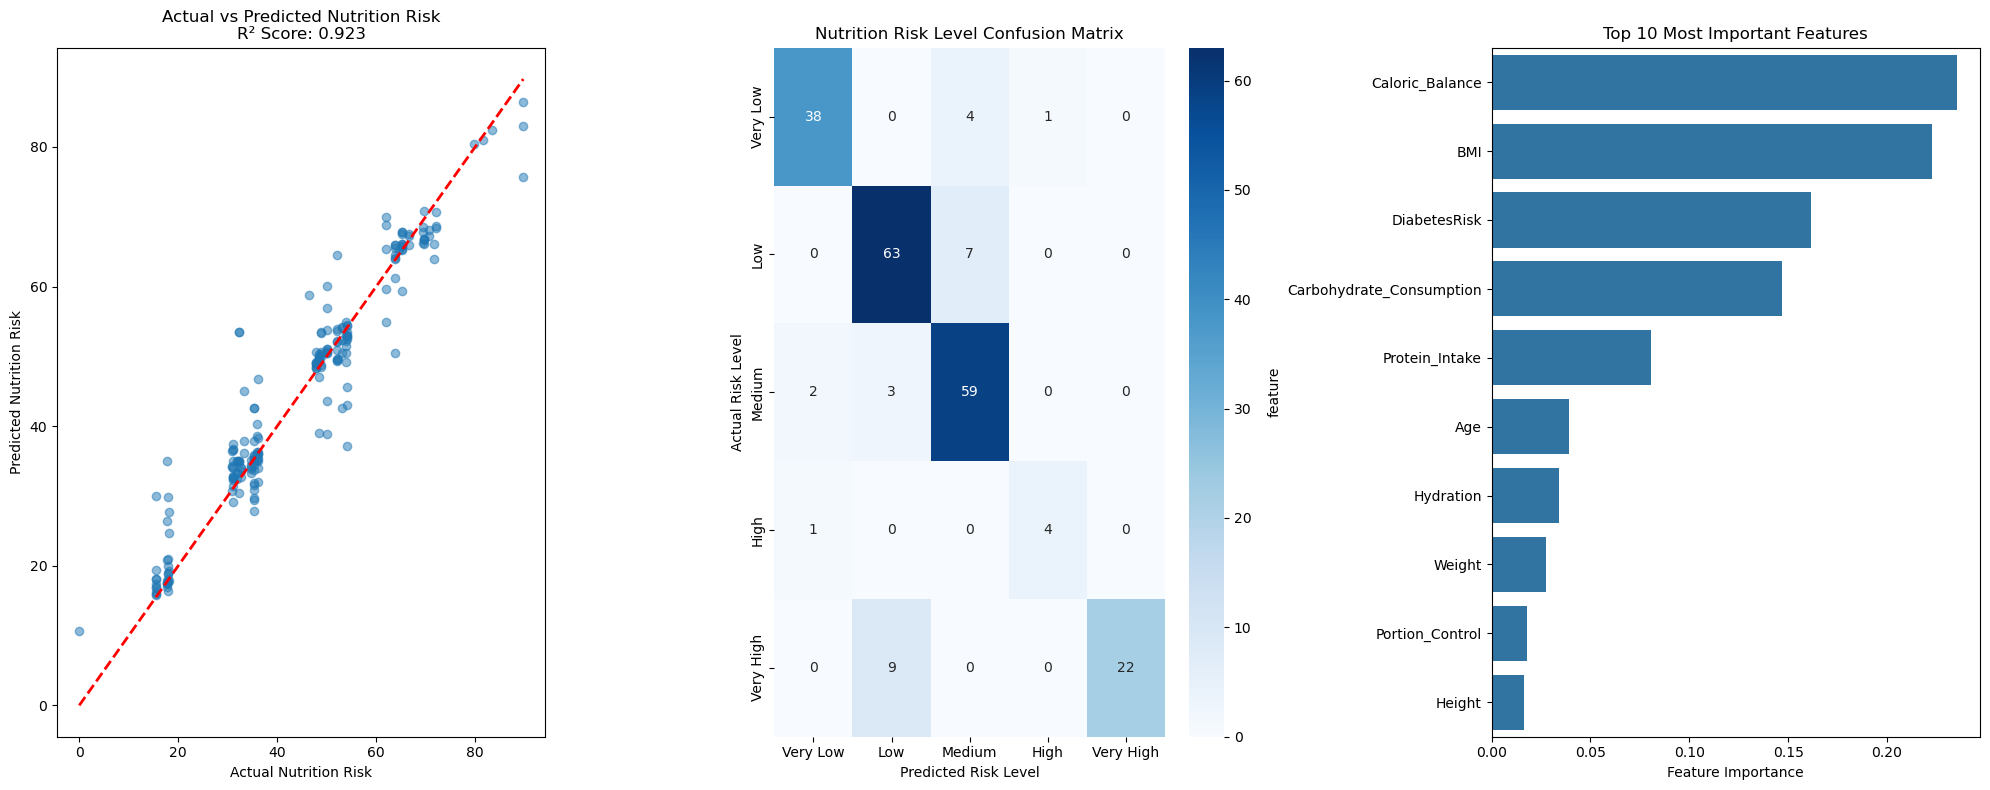


Random Forest Regression Metrics:
R² Score: 0.923
Mean Absolute Error: 3.130
Root Mean Squared Error: 4.929

Classification Report for Risk Levels:
              precision    recall  f1-score   support

        High       0.93      0.88      0.90        43
         Low       0.84      0.90      0.87        70
      Medium       0.84      0.92      0.88        64
   Very High       0.80      0.80      0.80         5
    Very Low       1.00      0.71      0.83        31

    accuracy                           0.87       213
   macro avg       0.88      0.84      0.86       213
weighted avg       0.88      0.87      0.87       213


Sample Predictions (First 10):
Actual Risk | Predicted Risk | Difference | Risk Level (Actual → Predicted)
---------------------------------------------------------------------------
     18.04 |         17.81 |       0.23 | Very Low → Very Low
     35.38 |         35.25 |       0.13 | Low → Low
     48.50 |         39.02 |       9.48 | Medium → Low
     34.7

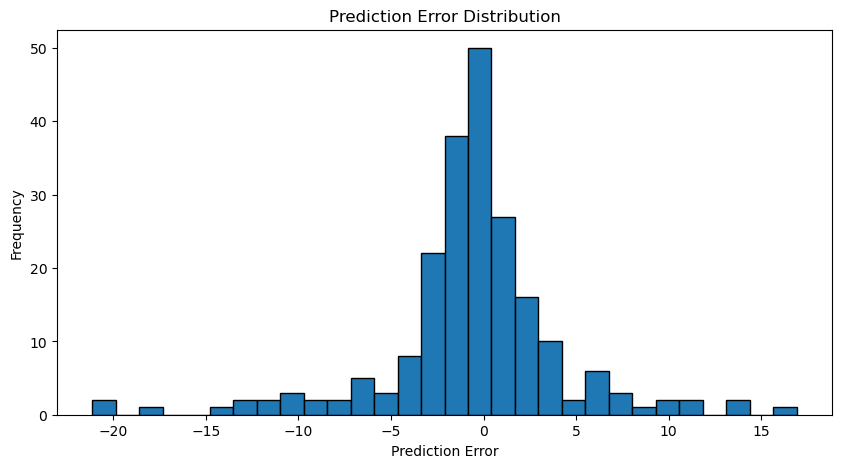

In [18]:
# After your existing model training code, add:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Train Random Forest model with better parameters
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Create figure with multiple subplots
plt.figure(figsize=(20, 8))

# 1. Scatter plot of Actual vs Predicted values
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Nutrition Risk')
plt.ylabel('Predicted Nutrition Risk')
plt.title('Actual vs Predicted Nutrition Risk\nR² Score: {:.3f}'.format(r2_score(y_test, y_pred)))

# 2. Create bins for confusion matrix-style visualization
# Define risk levels based on your data distribution
bins = [0, 20, 40, 60, 80, 100]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

y_test_binned = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)
y_pred_binned = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True)

# Calculate confusion matrix
cm = confusion_matrix(y_test_binned, y_pred_binned)

# Plot confusion matrix
plt.subplot(1, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Nutrition Risk Level Confusion Matrix')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')

# 3. Feature Importance Plot
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.subplot(1, 3, 3)
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance')

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\nRandom Forest Regression Metrics:")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# Print classification report for binned predictions
from sklearn.metrics import classification_report
print("\nClassification Report for Risk Levels:")
print(classification_report(y_test_binned, y_pred_binned))

# Print prediction examples
print("\nSample Predictions (First 10):")
print("Actual Risk | Predicted Risk | Difference | Risk Level (Actual → Predicted)")
print("-" * 75)
for actual, pred, act_bin, pred_bin in zip(y_test[:10], y_pred[:10], y_test_binned[:10], y_pred_binned[:10]):
    print(f"{actual:10.2f} | {pred:13.2f} | {abs(actual - pred):10.2f} | {act_bin} → {pred_bin}")

# Calculate error distribution
errors = y_test - y_pred
print("\nError Distribution:")
print(f"Mean Error: {np.mean(errors):.3f}")
print(f"Error Std Dev: {np.std(errors):.3f}")
print(f"Error Range: [{np.min(errors):.3f}, {np.max(errors):.3f}]")

# Plot error distribution
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()